In [2]:
import pandas as pd
import numpy as np

In [3]:
df=pd.read_csv(r"C:\Users\abhis\Desktop\Updated_Fraud_detection\data\Fraud.csv")
df

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.00,160296.36,M1979787155,0.00,0.00,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.00,19384.72,M2044282225,0.00,0.00,0,0
2,1,TRANSFER,181.00,C1305486145,181.00,0.00,C553264065,0.00,0.00,1,0
3,1,CASH_OUT,181.00,C840083671,181.00,0.00,C38997010,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.00,29885.86,M1230701703,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,C786484425,339682.13,0.00,C776919290,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,C1529008245,6311409.28,0.00,C1881841831,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,C1162922333,6311409.28,0.00,C1365125890,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,C1685995037,850002.52,0.00,C2080388513,0.00,0.00,1,0


In [4]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB


,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [5]:
df=df.drop(columns=['nameOrig','nameDest'])
df

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,170136.00,160296.36,0.00,0.00,0,0
1,1,PAYMENT,1864.28,21249.00,19384.72,0.00,0.00,0,0
2,1,TRANSFER,181.00,181.00,0.00,0.00,0.00,1,0
3,1,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1,0
4,1,PAYMENT,11668.14,41554.00,29885.86,0.00,0.00,0,0
...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,339682.13,0.00,0.00,339682.13,1,0
6362616,743,TRANSFER,6311409.28,6311409.28,0.00,0.00,0.00,1,0
6362617,743,CASH_OUT,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,0
6362618,743,TRANSFER,850002.52,850002.52,0.00,0.00,0.00,1,0


In [6]:
df['balance_diff_org']=df['oldbalanceOrg']-df['newbalanceOrig']
df['balance_diff_dest']=df['oldbalanceDest']-df['newbalanceDest']
df['amount_ratio']=df['amount']/(df['oldbalanceOrg']+1)
df["is_zero_balance"]=(df['newbalanceOrig']==0).astype(int)
df

,step,type,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,balance_diff_org,balance_diff_dest,amount_ratio,is_zero_balance
0,1,PAYMENT,9839.64,170136.00,160296.36,0.00,0.00,0,0,9839.64,0.00,0.057834,0
1,1,PAYMENT,1864.28,21249.00,19384.72,0.00,0.00,0,0,1864.28,0.00,0.087731,0
2,1,TRANSFER,181.00,181.00,0.00,0.00,0.00,1,0,181.00,0.00,0.994505,1
3,1,CASH_OUT,181.00,181.00,0.00,21182.00,0.00,1,0,181.00,21182.00,0.994505,1
4,1,PAYMENT,11668.14,41554.00,29885.86,0.00,0.00,0,0,11668.14,0.00,0.280788,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,339682.13,0.00,0.00,339682.13,1,0,339682.13,-339682.13,0.999997,1
6362616,743,TRANSFER,6311409.28,6311409.28,0.00,0.00,0.00,1,0,6311409.28,0.00,1.000000,1
6362617,743,CASH_OUT,6311409.28,6311409.28,0.00,68488.84,6379898.11,1,0,6311409.28,-6311409.27,1.000000,1
6362618,743,TRANSFER,850002.52,850002.52,0.00,0.00,0.00,1,0,850002.52,0.00,0.999999,1


In [7]:
df=df.drop(columns=['newbalanceOrig','newbalanceDest'])
df

,step,type,amount,oldbalanceOrg,oldbalanceDest,isFraud,isFlaggedFraud,balance_diff_org,balance_diff_dest,amount_ratio,is_zero_balance
0,1,PAYMENT,9839.64,170136.00,0.00,0,0,9839.64,0.00,0.057834,0
1,1,PAYMENT,1864.28,21249.00,0.00,0,0,1864.28,0.00,0.087731,0
2,1,TRANSFER,181.00,181.00,0.00,1,0,181.00,0.00,0.994505,1
3,1,CASH_OUT,181.00,181.00,21182.00,1,0,181.00,21182.00,0.994505,1
4,1,PAYMENT,11668.14,41554.00,0.00,0,0,11668.14,0.00,0.280788,0
...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,CASH_OUT,339682.13,339682.13,0.00,1,0,339682.13,-339682.13,0.999997,1
6362616,743,TRANSFER,6311409.28,6311409.28,0.00,1,0,6311409.28,0.00,1.000000,1
6362617,743,CASH_OUT,6311409.28,6311409.28,68488.84,1,0,6311409.28,-6311409.27,1.000000,1
6362618,743,TRANSFER,850002.52,850002.52,0.00,1,0,850002.52,0.00,0.999999,1


In [8]:
df=pd.get_dummies(df,columns=['type'],drop_first=True)
df

,step,amount,oldbalanceOrg,oldbalanceDest,isFraud,isFlaggedFraud,balance_diff_org,balance_diff_dest,amount_ratio,is_zero_balance,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER
0,1,9839.64,170136.00,0.00,0,0,9839.64,0.00,0.057834,0,False,False,True,False
1,1,1864.28,21249.00,0.00,0,0,1864.28,0.00,0.087731,0,False,False,True,False
2,1,181.00,181.00,0.00,1,0,181.00,0.00,0.994505,1,False,False,False,True
3,1,181.00,181.00,21182.00,1,0,181.00,21182.00,0.994505,1,True,False,False,False
4,1,11668.14,41554.00,0.00,0,0,11668.14,0.00,0.280788,0,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362615,743,339682.13,339682.13,0.00,1,0,339682.13,-339682.13,0.999997,1,True,False,False,False
6362616,743,6311409.28,6311409.28,0.00,1,0,6311409.28,0.00,1.000000,1,False,False,False,True
6362617,743,6311409.28,6311409.28,68488.84,1,0,6311409.28,-6311409.27,1.000000,1,True,False,False,False
6362618,743,850002.52,850002.52,0.00,1,0,850002.52,0.00,0.999999,1,False,False,False,True


In [9]:
from sklearn.model_selection import train_test_split
x=df.drop(columns=['isFraud'],axis=1)
y=df['isFraud']

In [10]:
x_train,x_test,y_train,y_test =train_test_split(x,y,test_size=0.2,random_state=42,stratify=y)

In [11]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
x_train_res,y_train_res=smote.fit_resample(x_train,y_train)

In [12]:
from xgboost import XGBClassifier
model = XGBClassifier(
    n_estimators=200,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    gamma=1,
    random_state=42,
    n_jobs=-1
)


model.fit(x_train_res,y_train_res)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=1, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.05, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=6,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=200,
              n_jobs=-1, num_parallel_tree=None, ...)

In [13]:
y_pred = model.predict(x_test)
print(y_pred)


[0 0 0 ... 0 0 0]


In [14]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)

[[1270687     194]
 [      3    1640]]


In [15]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.89      1.00      0.94      1643

    accuracy                           1.00   1272524
   macro avg       0.95      1.00      0.97   1272524
weighted avg       1.00      1.00      1.00   1272524



In [16]:
from sklearn.metrics import roc_auc_score

y_prob = model.predict_proba(x_test)[:, 1]
print(roc_auc_score(y_test, y_prob))


0.9997988561122386


In [17]:
# Change threshold from default 0.5 → 0.3
y_pred_03 = (y_prob > 0.3).astype(int)

from sklearn.metrics import confusion_matrix, classification_report

print("🔹 Threshold = 0.3")
print(confusion_matrix(y_test, y_pred_03))
print(classification_report(y_test, y_pred_03))


🔹 Threshold = 0.3
[[1270576     305]
 [      2    1641]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.84      1.00      0.91      1643

    accuracy                           1.00   1272524
   macro avg       0.92      1.00      0.96   1272524
weighted avg       1.00      1.00      1.00   1272524



In [18]:
y_pred_05 = (y_prob > 0.5).astype(int)

print("🔹 Threshold = 0.5")
print(confusion_matrix(y_test, y_pred_05))
print(classification_report(y_test, y_pred_05))


🔹 Threshold = 0.5
[[1270687     194]
 [      3    1640]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1270881
           1       0.89      1.00      0.94      1643

    accuracy                           1.00   1272524
   macro avg       0.95      1.00      0.97   1272524
weighted avg       1.00      1.00      1.00   1272524



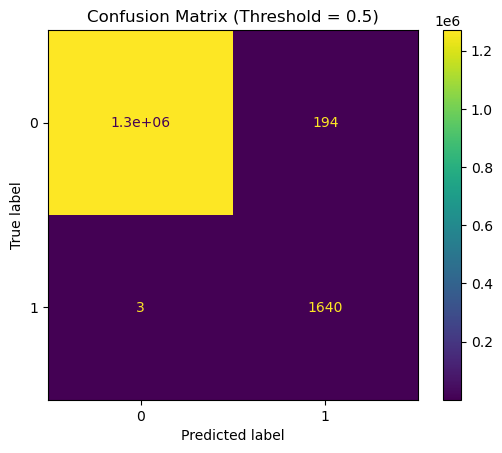

In [19]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred_05)
plt.title("Confusion Matrix (Threshold = 0.5)")
plt.show()


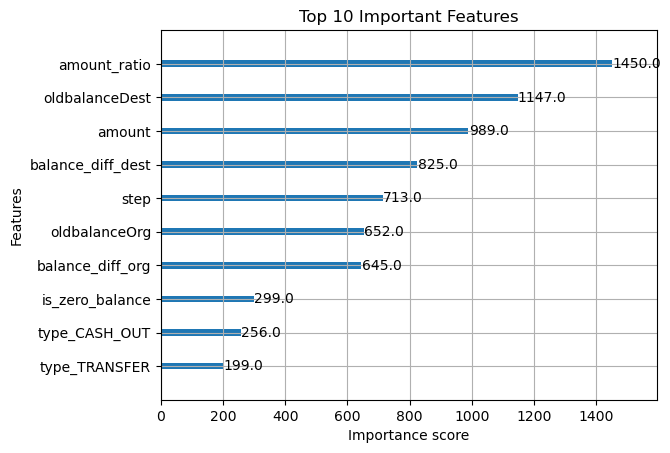

In [20]:
from xgboost import plot_importance
import matplotlib.pyplot as plt

plot_importance(model, max_num_features=10)
plt.title("Top 10 Important Features")
plt.show()


In [21]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import cross_val_score

pipeline = Pipeline([
    ('smote', SMOTE(random_state=42)),
    ('model', model)
])

scores = cross_val_score(pipeline, x, y, cv=5, scoring='roc_auc')
print("Cross-Validated ROC-AUC:", scores.mean())


Cross-Validated ROC-AUC: 0.9994112278996555


In [22]:
import joblib
joblib.dump(model,"model.pkl")

['model.pkl']